# VANILLA EUROPEAN STYLE OPTIONS

## Theory

A European vanilla option gives the holder the right, but not the obligation, to buy (call) or sell (put) an underlying asset at a fixed price (strike K) at a specific date (maturity T). It can only be exercised at expiry — not before.

*Who uses it and why?*

- Investors use calls to gain leveraged upside exposure without holding the underlying
- Investors use puts to hedge downside risk on existing positions
- Structured products desks use them as building blocks for more complex payoffs

### Payoff

$$C = \max(S_T - K, 0)$$
$$P = \max(K - S_T, 0)$$

### Pricing - Black-Scholes-Merton

$$C = S_0 e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S_0 e^{-qT} N(-d_1)$$

where:

$$d_1 = \frac{\ln(S_0/K) + \left(r - q + \frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}$$
$$d_2 = d_1 - \sigma\sqrt{T}$$

where $S_0$ is the current spot price, $K$ the strike, $r$ the risk-free rate, $q$ the continuous dividend yield, $\sigma$ the volatility, and $T$ the time to maturity.

### Key intuition

- $N(d_2)$ is the risk-neutral probability of finishing in the money
- $N(d_1)$ is the delta — sensitivity of the price to spot
- The further OTM, the lower both probabilities and the cheaper the option

## Pricing

In [2]:
from black_scholes_pricer import *
import numpy as np
import matplotlib.pyplot as plt

In [3]:
S, K, r, sigma, T, q = 100, 100, 0.05, 0.2, 1, 0.03

In [4]:
closed_form = BS_Analytical()
monte_carlo = BS_MonteCarlo()

In [5]:
call_option = EuropeanOption(S, K, r, sigma, T, q, option_type='call')
put_option = EuropeanOption(S, K, r, sigma, T, q, option_type='put')

In [8]:
print(f'Call Option Price using closed form solution: {closed_form.eu_vanilla_option_price(call_option):.2f}')
print(f'Put Option Price using closed form solution: {closed_form.eu_vanilla_option_price(put_option):.2f}')

Call Option Price using closed form solution: 17.75
Put Option Price using closed form solution: 17.36


In [9]:
print(f'Call Option Price using Monte Carlo simulations: {monte_carlo.eu_vanilla_option_price(call_option):.2f}')
print(f'Put Option Price using Monte Carlo simulations: {monte_carlo.eu_vanilla_option_price(put_option):.2f}')

Call Option Price using Monte Carlo simulations: 17.97
Put Option Price using Monte Carlo simulations: 17.18


## Sensitivities

### Price vs Spot

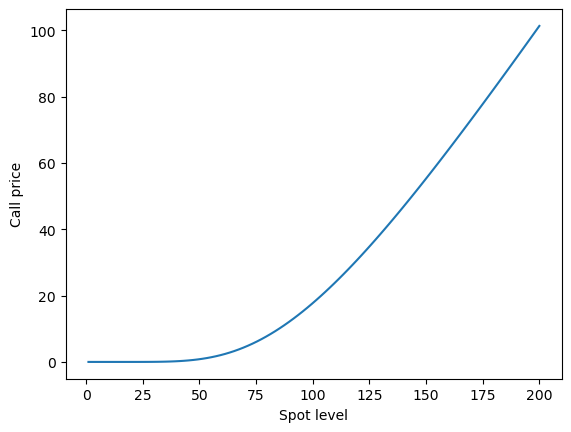

In [15]:
spot_range = np.linspace(S*0.01, S*2, 100)

call_option = EuropeanOption(spot_range, K, r, sigma, T, q, option_type='call')
call_price = closed_form.eu_vanilla_option_price(call_option)

plt.plot(spot_range, call_price)
plt.xlabel('Spot level')
plt.ylabel('Call price')
plt.show()

### Price vs Vol

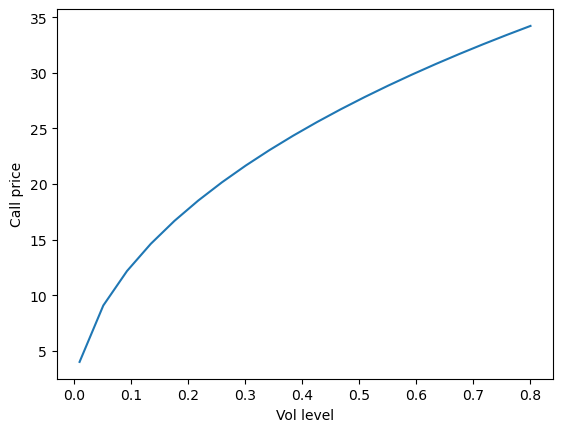

In [16]:
vol_range = np.linspace(0.01, 0.8, 20)

call_option = EuropeanOption(S, K, r, vol_range, T, q, option_type='call')
call_price = closed_form.eu_vanilla_option_price(call_option)

plt.plot(vol_range, call_price)
plt.xlabel('Vol level')
plt.ylabel('Call price')
plt.show()

### Price vs TTM

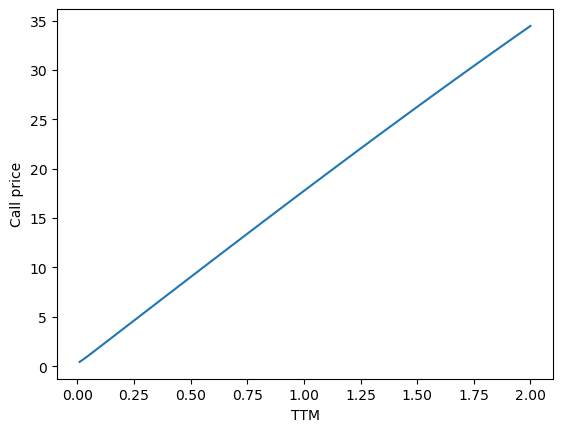

In [17]:
ttm_range = np.linspace(T*0.01, T*2, 100)

call_option = EuropeanOption(S, K, r, sigma, ttm_range, q, option_type='call')
call_price = closed_form.eu_vanilla_option_price(call_option)

plt.plot(ttm_range, call_price)
plt.xlabel('TTM')
plt.ylabel('Call price')
plt.show()

In [25]:
call_option = EuropeanOption(S, K, r, sigma, T, q, option_type='call')
call_greeks = closed_form.eu_vanilla_option_greeks(call_option)

for i, val in call_greeks.items():
    print(i + ': ', round(val,2))

Delta:  0.59
Gamma:  0.01
Theta:  -0.12
Vega:  17.37
Rho:  0.08
Vanna:  0.08
Volga:  -0.87
Charm:  -0.25


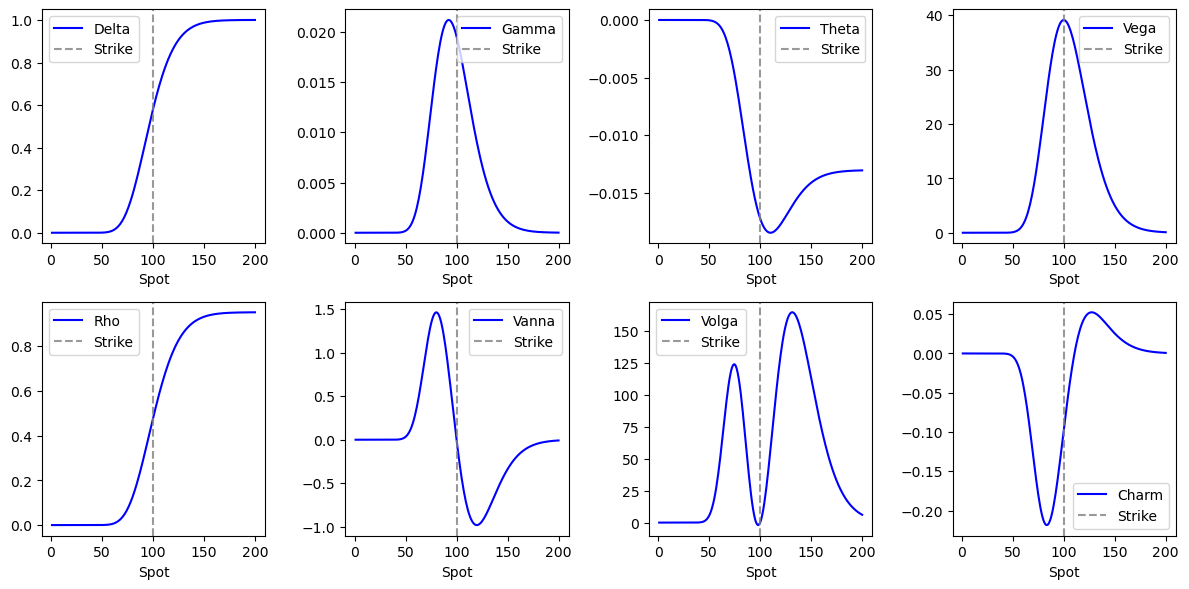

In [18]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
metrics = ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho', 'Vanna', 'Volga', 'Charm']

val = {j: [] for j in metrics}

for j in metrics:
    for i in spot_range:
        option = EuropeanOption(i, K, r, T, sigma, q, 'call')
        greek = closed_form.eu_vanilla_option_greeks(option)[j]
        val[j].append(greek)

plt.figure(figsize=(12,6))

for idx, i in enumerate(val):
    plt.subplot(2, 4, idx+1)
    plt.plot(spot_range, val[i], label=i, color='blue')
    plt.axvline(x=K, color='grey', linestyle='--', label='Strike', alpha=0.8)
    plt.xlabel('Spot')
    plt.legend()

plt.tight_layout()
plt.show()

## Convergence

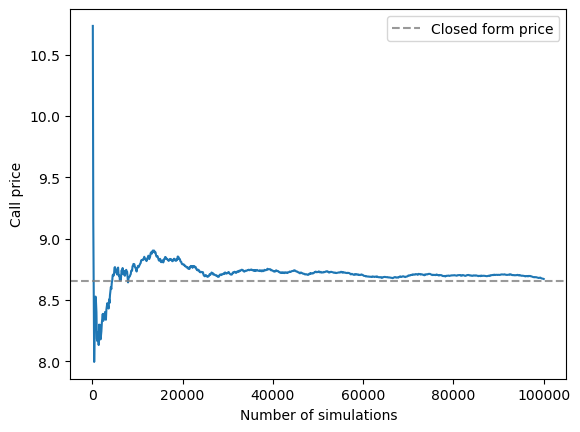

In [47]:
nb_sim = np.linspace(100, 100_000, 1000)
nb_sim = [int(i) for i in nb_sim]
prices = []

for i in nb_sim:
    option = EuropeanOption(S, K, r, T, sigma, q, 'call', nb_sim=i)
    price = monte_carlo.eu_vanilla_option_price(option)
    prices.append(price)

closed_form_price = closed_form.eu_vanilla_option_price(option)

plt.plot(nb_sim, prices)
plt.xlabel('Number of simulations')
plt.ylabel('Call price')
plt.axhline(closed_form_price, linestyle='dashed', color='grey', alpha=0.8, label='Closed form price')
plt.legend()
plt.show()

# 